# zedstat ROC convex-hull diagnostic

This notebook tests the current `zedstat` convex-hull path on the NERO ROC data without the older notebook's sampling/counting ambiguities.

zedstat loaded from:
/home/ishanu/.local/lib/python3.13/site-packages/zedstat/zedstat.py

processRoc signature:
(self, df=None, fprcol='fpr', tprcol='tpr', thresholdcol='threshold', prevalence=None, order=2, total_samples=None, positive_samples=None, alpha=0.05, lr_fpr_floor=0.001)

smooth signature:
(self, STEP=0.0001, interpolate=True, convexify=True)


LABEL CHECK
n = 6886
class 0 = 4383
class 1 = 2503
unique = [0 1]

ZEDSTAT STEP TEST


,STEP,n_points,AUC,monotone_FPR,monotone_TPR,ROCCH_concave,max_slope_increase
0,0.100,11,0.810393,True,True,True,4.440892e-16
1,0.050,21,0.817013,True,True,True,3.774758e-15
2,0.010,101,0.820150,True,True,True,2.220446e-14
3,0.005,201,0.820234,True,True,True,2.975398e-14
4,0.001,1001,0.820261,True,True,True,1.844080e-13



AUC STABILITY


,STEP,AUC,AUC_difference_from_0.001,ROCCH_concave
0,0.100,0.810393,-0.009867,True
1,0.050,0.817013,-0.003248,True
2,0.010,0.820150,-0.000111,True
3,0.005,0.820234,-0.000027,True
4,0.001,0.820261,0.000000,True


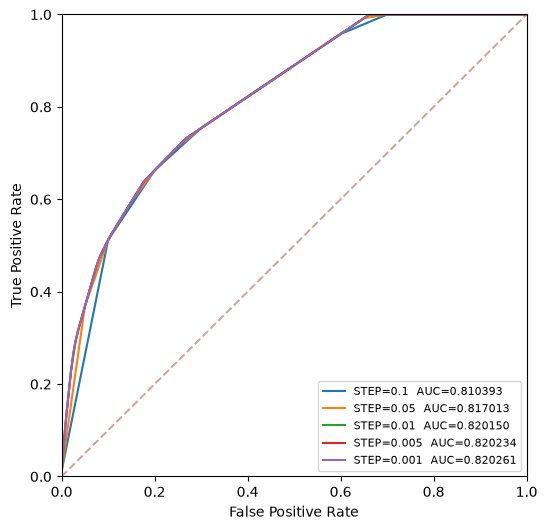


CURVE DIFFERENCES RELATIVE TO STEP=0.001
STEP=0.1    max |TPR difference| = 0.13228106, AUC difference = -0.00986732
STEP=0.05   max |TPR difference| = 0.07536636, AUC difference = -0.00324764
STEP=0.01   max |TPR difference| = 0.00606042, AUC difference = -0.00011066
STEP=0.005  max |TPR difference| = 0.00346310, AUC difference = -0.00002673


In [29]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import auc
from zedstat import zedstat


# ------------------------------------------------------------
# 1. Verify exactly which zedstat implementation is being used
# ------------------------------------------------------------

print("zedstat loaded from:")
print(zedstat.__file__)
print()

print("processRoc signature:")
print(inspect.signature(zedstat.processRoc.__init__))
print()

print("smooth signature:")
print(inspect.signature(zedstat.processRoc.smooth))
print()


# ------------------------------------------------------------
# 2. Load data CORRECTLY
# ------------------------------------------------------------

# ytrue.csv contains a saved pandas index in the first column.
ytrue = (
    pd.read_csv("notebooks/ytrue.csv", index_col=0)
      .iloc[:, 0]
      .to_numpy(dtype=int)
)

roc_df = pd.read_csv("notebooks/neroroce.csv")

print("\nLABEL CHECK")
print("n =", len(ytrue))
print("class 0 =", np.sum(ytrue == 0))
print("class 1 =", np.sum(ytrue == 1))
print("unique =", np.unique(ytrue))

# NERO ROC was generated using pos_label=0,
# so class 0 is the positive class for zedstat bounds.
n_pos = int(np.sum(ytrue == 0))
n_total = len(ytrue)

assert 0 < n_pos < n_total


# ------------------------------------------------------------
# 3. Helper: run zedstat at a specified STEP
# ------------------------------------------------------------

def run_zedstat(step):

    zt = zedstat.processRoc(
        df=roc_df,
        total_samples=n_total,
        positive_samples=n_pos,
        alpha=0.01,
        prevalence=0.5,
    )

    zt.smooth(
        STEP=step,
        interpolate=True,
        convexify=True,
    )

    # Do NOT usample here:
    # we want to inspect exactly what smooth() produced.
    out = zt.get().copy()

    fpr = out.index.to_numpy(dtype=float)
    tpr = out["tpr"].to_numpy(dtype=float)

    # ROC monotonicity
    monotone_fpr = np.all(np.diff(fpr) > -1e-12)
    monotone_tpr = np.all(np.diff(tpr) >= -1e-12)

    # Concavity test:
    # upper ROC convex hull must have non-increasing slopes.
    dx = np.diff(fpr)
    dy = np.diff(tpr)

    good = dx > 1e-12
    slopes = dy[good] / dx[good]

    concave = (
        True
        if len(slopes) < 2
        else np.all(np.diff(slopes) <= 1e-8)
    )

    roc_auc = auc(fpr, tpr)

    return {
        "step": step,
        "n_points": len(out),
        "auc": roc_auc,
        "monotone_fpr": monotone_fpr,
        "monotone_tpr": monotone_tpr,
        "concave": concave,
        "max_slope_increase":
            np.nan if len(slopes) < 2
            else np.max(np.diff(slopes)),
        "object": zt,
        "df": out,
        "slopes": slopes,
    }


# ------------------------------------------------------------
# 4. Test several STEP values
# ------------------------------------------------------------

steps = [0.1, 0.05, 0.01, 0.005, 0.001]

results = [run_zedstat(s) for s in steps]

summary = pd.DataFrame([
    {
        "STEP": r["step"],
        "n_points": r["n_points"],
        "AUC": r["auc"],
        "monotone_FPR": r["monotone_fpr"],
        "monotone_TPR": r["monotone_tpr"],
        "ROCCH_concave": r["concave"],
        "max_slope_increase": r["max_slope_increase"],
    }
    for r in results
])

print("\nZEDSTAT STEP TEST")
display(summary)


# ------------------------------------------------------------
# 5. Critical test:
#    convex-hull AUC should not materially depend on STEP
# ------------------------------------------------------------

reference_auc = results[-1]["auc"]   # STEP = 0.001

summary["AUC_difference_from_0.001"] = (
    summary["AUC"] - reference_auc
)

print("\nAUC STABILITY")
display(
    summary[
        [
            "STEP",
            "AUC",
            "AUC_difference_from_0.001",
            "ROCCH_concave",
        ]
    ]
)


# ------------------------------------------------------------
# 6. Plot all STEP choices together
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

for r in results:
    d = r["df"]

    plt.plot(
        d.index,
        d["tpr"],
        label=f"STEP={r['step']}  AUC={r['auc']:.6f}"
    )

plt.plot([0, 1], [0, 1], "--", alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(fontsize=8)

plt.show()


# ------------------------------------------------------------
# 7. Quantify differences between coarse and fine curves
# ------------------------------------------------------------

fine = results[-1]["df"]

fine_fpr = fine.index.to_numpy(dtype=float)
fine_tpr = fine["tpr"].to_numpy(dtype=float)

print("\nCURVE DIFFERENCES RELATIVE TO STEP=0.001")

for r in results[:-1]:

    d = r["df"]

    coarse_fpr = d.index.to_numpy(dtype=float)
    coarse_tpr = d["tpr"].to_numpy(dtype=float)

    # put coarse curve onto the fine grid
    coarse_on_fine = np.interp(
        fine_fpr,
        coarse_fpr,
        coarse_tpr
    )

    diff = fine_tpr - coarse_on_fine

    print(
        f"STEP={r['step']:<6} "
        f"max |TPR difference| = {np.max(np.abs(diff)):.8f}, "
        f"AUC difference = {r['auc'] - reference_auc:+.8f}"
    )

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from zedstat import zedstat

# ytrue.csv was written with a pandas index, so read that index back as index.
# The remaining single column is the actual binary label vector.
ytrue = pd.read_csv('notebooks/ytrue.csv', index_col=0).iloc[:, 0].to_numpy(dtype=int)
roc_df = pd.read_csv('notebooks/neroroce.csv')

print('n =', len(ytrue))
print('class counts:', {0: int(np.sum(ytrue == 0)), 1: int(np.sum(ytrue == 1))})
print(roc_df[['fpr', 'tpr']].describe())

n = 6886
class counts: {0: 4383, 1: 2503}
               fpr          tpr
count  5427.000000  5427.000000
mean      0.441622     0.640609
std       0.297159     0.240178
min       0.000000     0.000000
25%       0.175390     0.461442
50%       0.412705     0.683322
75%       0.689573     0.843943
max       1.000000     1.000000


In [27]:
# neroroce.csv was constructed with pos_label=0, therefore positive_samples
# must count class 0, not ytrue.sum().
zte = zedstat.processRoc(
    df=roc_df,
    total_samples=len(ytrue),
    positive_samples=int(np.sum(ytrue == 0)),
    alpha=0.01,
    prevalence=0.5,
)

# STEP is FPR grid resolution, not smoothing strength. Keep it fine.
zte.smooth(STEP=0.001, interpolate=True, convexify=True)
zte.allmeasures(interpolate=False)
zte.getBounds()

print('AUC (nominal, upper, lower):', zte.auc(alpha=0.05))

AUC (nominal, upper, lower): (0.7184941638592834, np.float64(0.7304243847686873), np.float64(0.7065639429498796))


strictly increasing FPR: True
nondecreasing TPR: False
concave / ROCCH slopes non-increasing: False
largest slope increase: 591.8794204882497


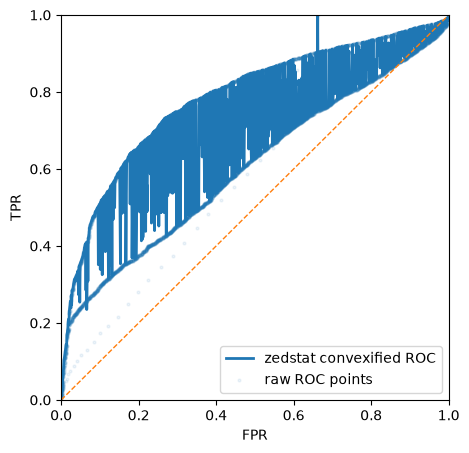

In [28]:
# Verify that the nominal curve returned by zedstat is a valid upper ROC hull:
# TPR must be nondecreasing and secant slopes must be non-increasing.
out = zte.get()[['tpr']].copy()
fpr = out.index.to_numpy(dtype=float)
tpr = out['tpr'].to_numpy(dtype=float)
dx = np.diff(fpr)
dy = np.diff(tpr)
slopes = dy / dx
tol = 1e-9

print('strictly increasing FPR:', bool(np.all(dx > 0)))
print('nondecreasing TPR:', bool(np.all(dy >= -tol)))
print('concave / ROCCH slopes non-increasing:', bool(np.all(np.diff(slopes) <= tol)))
print('largest slope increase:', float(np.max(np.diff(slopes))))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, label='zedstat convexified ROC')
ax.scatter(roc_df['fpr'], roc_df['tpr'], s=4, alpha=0.08, label='raw ROC points')
ax.plot([0, 1], [0, 1], '--', lw=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.show()

If the last diagnostic reports a positive slope increase materially above numerical tolerance, the defect is in `zedstat`'s convexification/resampling path rather than in the NERO notebook.